# Anesthesia Outcome Prediction: End-to-End Data Audit & Machine Learning

This notebook documents the complete analytical workflow for the anesthesia ML portfolio project.

### What this notebook covers
- Dataset audit and quality checks
- Missing values and duplicates
- Exploratory Data Analysis (EDA)
- Surgery-duration feature engineering
- Statistical hypothesis testing and effect sizes
- Data leakage analysis
- Leakage-aware ML dataset construction
- Stratified cross-validation
- Logistic Regression, Decision Tree, Random Forest, and Gradient Boosting
- Hyperparameter tuning
- Holdout evaluation
- Confusion matrix, ROC and Precision-Recall curves
- Feature importance and SHAP
- Final model serialization for Streamlit

### Reproducibility principles
- Fixed `random_state=42`
- Preprocessing is inside Scikit-learn pipelines
- The test set is kept out of model selection and tuning
- Model comparison metrics are calculated from CV outputs rather than manually typed values
- The complete fitted pipeline is saved as the deployment artifact

> **Clinical disclaimer:** This project is for education/research and portfolio demonstration only. It is not a medical device or clinical decision-support system.

## Importing Libraries

The notebook uses Pandas/NumPy for data handling, SciPy for statistical testing, Scikit-learn for modeling, SHAP for explainability, and Joblib for model persistence.

In [4]:
import warnings
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import shap

from scipy.stats import chi2_contingency, mannwhitneyu

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    average_precision_score,
    confusion_matrix,
    f1_score,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import (
    GridSearchCV,
    StratifiedKFold,
    cross_validate,
    train_test_split,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.tree import DecisionTreeClassifier

warnings.filterwarnings("ignore")

RANDOM_STATE = 42
TARGET = "Outcome"

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

d:\Project\anesthesia-ml-project\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Project paths and reproducibility

This notebook is stored inside `notebooks/`, so project paths are resolved relative to the project root rather than the current working directory. This makes the notebook safer to run from different Jupyter launch locations.

In [5]:
PROJECT_ROOT = Path.cwd().resolve().parent

# Fallback when Jupyter is launched from the project root.
if not (PROJECT_ROOT / "data" / "raw").exists():
    PROJECT_ROOT = Path.cwd().resolve()

DATA_PATH = PROJECT_ROOT / "data" / "raw" / "Anesthesia_Dataset.csv"
MODEL_DIR = PROJECT_ROOT / "models"
MODEL_PATH = MODEL_DIR / "anesthesia_rf_model.pkl"

print("Project root:", PROJECT_ROOT)
print("Dataset path:", DATA_PATH)
print("Dataset exists:", DATA_PATH.exists())


Project root: D:\Project\anesthesia-ml-project
Dataset path: D:\Project\anesthesia-ml-project\data\raw\Anesthesia_Dataset.csv
Dataset exists: True


In [6]:
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

## Reading the Dataset:

The raw dataset is loaded from the project-level `data/raw/` directory.

In [7]:
df = pd.read_csv(DATA_PATH)
df.head()

,PatientID,Age,Gender,BMI,SurgeryType,SurgeryDuration,AnesthesiaType,PreoperativeNotes,PostoperativeNotes,PainLevel,Complications,Outcome
0,1,33,M,32,Neurological,217 min,Local,"Hypertension, diabetes","Minimal pain, no complications",7,NaN,0
1,2,33,M,23,Cardiovascular,181 min,Local,"Stable, no allergies","Minimal pain, no complications",7,"Nausea, mild bleeding",1
2,3,58,F,24,Orthopedic,79 min,General,"Stable, no allergies","Minimal pain, no complications",3,"Nausea, mild bleeding",1
3,4,65,F,26,Orthopedic,210 min,Local,"Stable, no allergies","Pain, slow recovery",7,Delayed recovery,1
4,5,65,M,28,Neurological,221 min,General,"Stable, no allergies","Pain, slow recovery",5,Respiratory distress,0


In [8]:
df.shape

(300, 12)

In [9]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype
---  ------              --------------  -----
 0   PatientID           300 non-null    int64
 1   Age                 300 non-null    int64
 2   Gender              300 non-null    str  
 3   BMI                 300 non-null    int64
 4   SurgeryType         300 non-null    str  
 5   SurgeryDuration     300 non-null    str  
 6   AnesthesiaType      300 non-null    str  
 7   PreoperativeNotes   300 non-null    str  
 8   PostoperativeNotes  300 non-null    str  
 9   PainLevel           300 non-null    int64
 10  Complications       227 non-null    str  
 11  Outcome             300 non-null    int64
dtypes: int64(5), str(7)
memory usage: 53.1 KB


## Checking Missing Values

We quantify both the number and percentage of missing observations in every column.

In [11]:
missing = df.isnull().sum()
missing_percentage = (missing / len(df)) * 100

missing_table = pd.DataFrame({
    "Missing Values": missing,
    "Missing Percentage": missing_percentage
})
missing_table.sort_values(by="Missing Values", ascending=False)

,Missing Values,Missing Percentage
Complications,73,24.333333
PatientID,0,0.000000
Gender,0,0.000000
Age,0,0.000000
BMI,0,0.000000
SurgeryType,0,0.000000
AnesthesiaType,0,0.000000
SurgeryDuration,0,0.000000
PreoperativeNotes,0,0.000000
PostoperativeNotes,0,0.000000


## Checking Duplicated Values:

Duplicate rows and duplicate patient identifiers are checked before analysis.

In [12]:
df.duplicated().sum()

np.int64(0)

In [13]:
df["PatientID"].duplicated().sum()

np.int64(0)

## Checking Target:

The target distribution is inspected to verify class balance.

In [14]:
outcome = df["Outcome"].value_counts()
outcome

Outcome
0    150
1    150
Name: count, dtype: int64

In [15]:
df["Outcome"].value_counts(normalize=True) * 100

Outcome
0    50.0
1    50.0
Name: proportion, dtype: float64

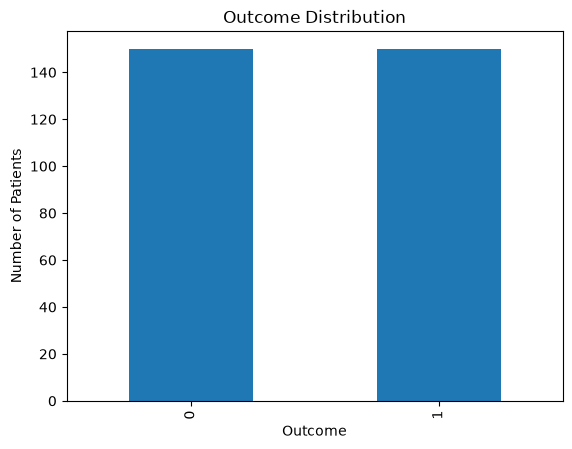

In [16]:
outcome.plot(kind="bar", title="Outcome Distribution")
plt.xlabel("Outcome")
plt.ylabel('Number of Patients')
plt.show()

## Checking Unique Columns:

Unique-value counts help identify categorical structure, repeated text patterns, and possible data-quality issues.

In [17]:
for column in df.columns:
    print("\n" + "=" * 50)
    print(column)
    print(f"Unique values: {df[column].nunique(dropna=True)}")
    print(df[column].dropna().unique()[:20])



PatientID
Unique values: 300
[ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20]

Age
Unique values: 6
[33 58 65 45 51 72]

Gender
Unique values: 2
<ArrowStringArray>
['M', 'F']
Length: 2, dtype: str

BMI
Unique values: 6
[32 23 24 26 28 30]

SurgeryType
Unique values: 4
<ArrowStringArray>
['Neurological', 'Cardiovascular', 'Orthopedic', 'Cosmetic']
Length: 4, dtype: str

SurgeryDuration
Unique values: 139
<ArrowStringArray>
['217 min', '181 min',  '79 min', '210 min', '221 min',  '82 min',  '96 min',
 '226 min', '207 min', '118 min', '171 min', '116 min', '231 min', '156 min',
 '188 min', '215 min', '199 min', '119 min',  '91 min', '127 min']
Length: 20, dtype: str

AnesthesiaType
Unique values: 2
<ArrowStringArray>
['Local', 'General']
Length: 2, dtype: str

PreoperativeNotes
Unique values: 2
<ArrowStringArray>
['Hypertension, diabetes', 'Stable, no allergies']
Length: 2, dtype: str

PostoperativeNotes
Unique values: 2
<ArrowStringArray>
['Minimal pain, no complications', 

## Checking Numerical Values:

Descriptive statistics provide the basic distribution of the numerical variables.

In [18]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
PatientID,300.0,150.500000,86.746758,1.0,75.75,150.5,225.25,300.0
Age,300.0,54.246667,12.841163,33.0,45.00,58.0,65.00,72.0
BMI,300.0,27.056667,3.091707,23.0,24.00,26.0,30.00,32.0
PainLevel,300.0,4.496667,1.646925,2.0,3.00,4.0,6.00,7.0
Outcome,300.0,0.500000,0.500835,0.0,0.00,0.5,1.00,1.0


The target variable is perfectly balanced, eliminating the need for class-balancing techniques during the initial modeling stage.

## Checking Relations Feature / Outcome:

Features are compared across the two outcome classes to identify visible distributional differences.

In [19]:
df.groupby("Outcome")[['Age', 'BMI', 'PainLevel']].agg(['mean', 'median', 'std', 'min', 'max'])

Age                                  BMI                       \
              mean median        std min max       mean median       std min   
Outcome                                                                        
0        54.280000   51.0  12.170555  33  72  27.240000   28.0  3.123154  23   
1        54.213333   58.0  13.519356  33  72  26.873333   26.0  3.059361  23   

            PainLevel                           
        max      mean median       std min max  
Outcome                                         
0        32  4.560000    4.0  1.607366   2   7  
1        32  4.433333    4.0  1.688559   2   7

In [20]:
pd.crosstab(df["Outcome"], df['Gender'], normalize='index') * 100

Gender,F,M
Outcome,,
0,51.333333,48.666667
1,45.333333,54.666667


In [21]:
pd.crosstab(df["Outcome"], df['SurgeryType'], normalize='index') * 100

SurgeryType,Cardiovascular,Cosmetic,Neurological,Orthopedic
Outcome,,,,
0,24.666667,21.333333,26.666667,27.333333
1,26.000000,32.000000,17.333333,24.666667


In [22]:
pd.crosstab(df["Outcome"], df['AnesthesiaType'], normalize='index') * 100

AnesthesiaType,General,Local
Outcome,,
0,46.666667,53.333333
1,52.666667,47.333333


In [23]:
pd.crosstab(df["Outcome"], df['Complications'], normalize='index') * 100

Complications,Delayed recovery,"Nausea, mild bleeding",Respiratory distress
Outcome,,,
0,29.464286,32.142857,38.392857
1,26.956522,38.260870,34.782609


In [24]:
pd.crosstab(df["Outcome"], df['PostoperativeNotes'], normalize='index') * 100

PostoperativeNotes,"Minimal pain, no complications","Pain, slow recovery"
Outcome,,
0,53.333333,46.666667
1,48.000000,52.000000


## Checking SurgeryDuration:

Surgery duration is inspected because it is stored as text and must be converted before statistical analysis and modeling.

In [25]:
df['SurgeryDuration'].head(20)

0     217 min
1     181 min
2      79 min
3     210 min
4     221 min
5      82 min
6      96 min
7     210 min
8     226 min
9     207 min
10    118 min
11    171 min
12    116 min
13    231 min
14    156 min
15    188 min
16    215 min
17    199 min
18    119 min
19     91 min
Name: SurgeryDuration, dtype: str

In [26]:
df['SurgeryDuration'].str.extract(r'(\d+)')[0].astype(int).describe()

count    300.000000
mean     147.700000
std       51.558357
min       60.000000
25%      101.750000
50%      148.500000
75%      190.500000
max      240.000000
Name: 0, dtype: float64

In [27]:
df.groupby('Outcome')['SurgeryDuration'].apply(lambda x: x.str.extract(r'(\d+)')[0].astype(int).describe())

Outcome       
0        count    150.000000
         mean     148.600000
         std       51.318717
         min       62.000000
         25%      103.000000
         50%      150.000000
         75%      188.750000
         max      240.000000
1        count    150.000000
         mean     146.800000
         std       51.953128
         min       60.000000
         25%       97.500000
         50%      148.500000
         75%      191.500000
         max      240.000000
Name: SurgeryDuration, dtype: float64

In [28]:
df.groupby('Outcome')['SurgeryDuration'].apply(lambda x: x.str.extract(r'(\d+)')[0].astype(int).mean())

Outcome
0    148.6
1    146.8
Name: SurgeryDuration, dtype: float64

## Converting SurgeryDuration to int:

The numeric duration in minutes is extracted from strings such as `217 min`.

In [29]:
df['SurgeryDuration_min'] = (df['SurgeryDuration'].str.extract(r"(\d+)")[0].astype(int))
df[["SurgeryDuration", "SurgeryDuration_min"]].head()

,SurgeryDuration,SurgeryDuration_min
0,217 min,217
1,181 min,181
2,79 min,79
3,210 min,210
4,221 min,221


## Numerical Features:

Two-sided Mann-Whitney U tests are used for numerical comparisons because they do not require a normality assumption.

In [30]:
numeric_features = ["Age", "BMI", "SurgeryDuration_min"]

for feature in numeric_features:
    group_0 = df.loc[df["Outcome"] == 0, feature]
    group_1 = df.loc[df["Outcome"] == 1, feature]

    statistic, p_value = mannwhitneyu(group_0, group_1, alternative="two-sided")

    print(f"{feature}")
    print(f"U-statistic: {statistic:.2f}")
    print(f"p-value: {p_value:.4f}")
    print("-" * 40)

Age
U-statistic: 11129.50
p-value: 0.8713
----------------------------------------
BMI
U-statistic: 11995.00
p-value: 0.3147
----------------------------------------
SurgeryDuration_min
U-statistic: 11439.50
p-value: 0.8014
----------------------------------------


## Effect Size:

Rank-biserial correlation is reported alongside p-values to describe the magnitude and direction of numerical-group differences.

In [31]:
def rank_biserial_correlation(x, y):
    u, _ = mannwhitneyu(x, y, alternative="two-sided")
    n1 = len(x)
    n2 = len(y)

    return (2 * u) / (n1 * n2) - 1

for feature in numeric_features:
    group_0 = df.loc[df["Outcome"] == 0, feature]
    group_1 = df.loc[df["Outcome"] == 1, feature]

    effect_size = rank_biserial_correlation(group_0, group_1)

    print(f"{feature}: {effect_size:.4f}")

Age: -0.0107
BMI: 0.0662
SurgeryDuration_min: 0.0168


## Categorical Features:

Chi-square tests assess whether categorical variables are associated with the binary outcome.

In [32]:
categorical_features = ["Gender", "SurgeryType", "AnesthesiaType"]

for feature in categorical_features:
    contingency_table = pd.crosstab(df[feature], df["Outcome"])
    chi2, p_value, dof, expected = chi2_contingency(contingency_table)

    print(f"{feature}")
    print(f"Chi-square: {chi2:.4f}")
    print(f"p-value: {p_value:.4f}")
    print(f"Degrees of freedom: {dof}")
    print("-" * 40)

Gender
Chi-square: 0.8543
p-value: 0.3553
Degrees of freedom: 1
----------------------------------------
SurgeryType
Chi-square: 6.4275
p-value: 0.0926
Degrees of freedom: 3
----------------------------------------
AnesthesiaType
Chi-square: 0.8534
p-value: 0.3556
Degrees of freedom: 1
----------------------------------------


Univariate statistical analysis did not identify statistically significant associations between the available preoperative variables and the binary outcome. This does not imply that these variables are useless for multivariate prediction, as machine-learning models may capture nonlinearities and interactions between features.

## Effect size for Chi-square:

Cramer's V is reported as the effect size for categorical associations.

In [33]:
for feature in categorical_features:
    contingency_table = pd.crosstab(df[feature], df["Outcome"])
    chi2, p_value, dof, expected = chi2_contingency(contingency_table)
    n = contingency_table.values.sum()
    min_dimension = min(contingency_table.shape) - 1
    cramers_v = np.sqrt(chi2 / (n * min_dimension))

    print(f"{feature}")
    print(f"Chi-square: {chi2:.4f}")
    print(f"p-value: {p_value:.4f}")
    print(f"Cramer's V: {cramers_v:.4f}")
    print("-" * 40)

Gender
Chi-square: 0.8543
p-value: 0.3553
Cramer's V: 0.0534
----------------------------------------
SurgeryType
Chi-square: 6.4275
p-value: 0.0926
Cramer's V: 0.1464
----------------------------------------
AnesthesiaType
Chi-square: 0.8534
p-value: 0.3556
Cramer's V: 0.0533
----------------------------------------


SurgeryType showed the strongest categorical association with Outcome among the examined variables, although the association was not statistically significant at the 5% level.

## Data Cleaning:

This section documents missingness and prepares the leakage-aware modeling dataset.

In [34]:
df["Complications"].value_counts(dropna=False)

Complications
Respiratory distress     83
Nausea, mild bleeding    80
NaN                      73
Delayed recovery         64
Name: count, dtype: int64

In [35]:
pd.crosstab(df["Complications"].isna(), df["Outcome"], normalize="index") * 100

Outcome,0,1
Complications,,
False,49.339207,50.660793
True,52.054795,47.945205


## Preparing Dataset for ML:

Postoperative and identifier columns are excluded before model training.

In [36]:
df_ml = df.copy()
df_ml = df_ml.drop(columns=["PatientID","Complications","PostoperativeNotes","PainLevel"])
df_ml.columns

Index(['Age', 'Gender', 'BMI', 'SurgeryType', 'SurgeryDuration',
       'AnesthesiaType', 'PreoperativeNotes', 'Outcome',
       'SurgeryDuration_min'],
      dtype='str')

In [37]:
df_ml["SurgeryDuration_min"] = (df_ml["SurgeryDuration"].str.extract(r"(\d+)")[0].astype(int))
df_ml = df_ml.drop(columns=["SurgeryDuration"])
df_ml.head()

,Age,Gender,BMI,SurgeryType,AnesthesiaType,PreoperativeNotes,Outcome,SurgeryDuration_min
0,33,M,32,Neurological,Local,"Hypertension, diabetes",0,217
1,33,M,23,Cardiovascular,Local,"Stable, no allergies",1,181
2,58,F,24,Orthopedic,General,"Stable, no allergies",1,79
3,65,F,26,Orthopedic,Local,"Stable, no allergies",1,210
4,65,M,28,Neurological,General,"Stable, no allergies",0,221


In [38]:
df_ml.info()

<class 'pandas.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 8 columns):
 #   Column               Non-Null Count  Dtype
---  ------               --------------  -----
 0   Age                  300 non-null    int64
 1   Gender               300 non-null    str  
 2   BMI                  300 non-null    int64
 3   SurgeryType          300 non-null    str  
 4   AnesthesiaType       300 non-null    str  
 5   PreoperativeNotes    300 non-null    str  
 6   Outcome              300 non-null    int64
 7   SurgeryDuration_min  300 non-null    int64
dtypes: int64(4), str(4)
memory usage: 30.3 KB


## Feature Engineering:

Preoperative notes are converted into a binary comorbidity feature.

In [39]:
categorical_features = ["Gender", "SurgeryType", "AnesthesiaType", "PreoperativeNotes"]

for feature in categorical_features:
    print(f"\n{feature}")
    print(df_ml[feature].value_counts())


Gender
Gender
M    155
F    145
Name: count, dtype: int64

SurgeryType
SurgeryType
Cosmetic          80
Orthopedic        78
Cardiovascular    76
Neurological      66
Name: count, dtype: int64

AnesthesiaType
AnesthesiaType
Local      151
General    149
Name: count, dtype: int64

PreoperativeNotes
PreoperativeNotes
Hypertension, diabetes    157
Stable, no allergies      143
Name: count, dtype: int64


In [40]:
df_ml["Has_Comorbidities"] = (df_ml["PreoperativeNotes"].str.contains("Hypertension|diabetes", case=False, regex=True).astype(int))
df_ml = df_ml.drop(columns=["PreoperativeNotes"])
df_ml["Has_Comorbidities"].value_counts()

Has_Comorbidities
1    157
0    143
Name: count, dtype: int64

## Train/Test Split:

A stratified 80/20 split reserves an untouched test set for final evaluation.

In [41]:
X = df_ml.drop(columns=["Outcome"])
y = df_ml["Outcome"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

print("\nTrain target distribution:")
print(y_train.value_counts())

print("\nTest target distribution:")
print(y_test.value_counts())

Train shape: (240, 7)
Test shape: (60, 7)

Train target distribution:
Outcome
1    120
0    120
Name: count, dtype: int64

Test target distribution:
Outcome
0    30
1    30
Name: count, dtype: int64


## preprocessing pipeline:

Preprocessing is kept inside the modeling pipeline so scaling and encoding are learned only from training folds during cross-validation.

In [42]:
numeric_features = ["Age", "BMI", "SurgeryDuration_min", "Has_Comorbidities"]
categorical_features = ["Gender", "SurgeryType", "AnesthesiaType"]

def make_preprocessor():
    return ColumnTransformer(
        transformers=[
            ("num", StandardScaler(), numeric_features),
            ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
        ]
    )

# Do not fit this transformer outside cross-validation.
# Each model pipeline creates and fits its own preprocessing object.
preprocessor = make_preprocessor()

print("Numeric features:", numeric_features)
print("Categorical features:", categorical_features)


Numeric features: ['Age', 'BMI', 'SurgeryDuration_min', 'Has_Comorbidities']
Categorical features: ['Gender', 'SurgeryType', 'AnesthesiaType']


In [43]:
print("Raw training shape:", X_train.shape)
print("The preprocessing transformer is fitted inside each model pipeline.")


Raw training shape: (240, 7)
The preprocessing transformer is fitted inside each model pipeline.


## Pipeline Logistic Regression:

Logistic Regression provides a simple linear baseline.

In [44]:
baseline_model = Pipeline(steps=[("preprocessor", make_preprocessor()), ("classifier", LogisticRegression(max_iter=1000, random_state=42))])
baseline_model.fit(X_train, y_train)

y_pred = baseline_model.predict(X_test)
y_prob = baseline_model.predict_proba(X_test)[:, 1]

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob)
cm = confusion_matrix(y_test, y_pred)

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1-score : {f1:.4f}")
print(f"ROC-AUC  : {roc_auc:.4f}")
print(cm)

Accuracy : 0.6000
Precision: 0.6071
Recall   : 0.5667
F1-score : 0.5862
ROC-AUC  : 0.5667
[[19 11]
 [13 17]]


## Pipeline Cross-Validation:

Stratified 5-fold cross-validation estimates performance more reliably than a single split.

In [45]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE,
)

SCORING = ["accuracy", "precision", "recall", "f1", "roc_auc"]

baseline_model_cv_results = cross_validate(
    baseline_model,
    X_train,
    y_train,
    cv=cv,
    scoring=SCORING,
    n_jobs=-1,
)

def summarize_cv(results, model_name):
    return {
        "Model": model_name,
        "Accuracy": results["test_accuracy"].mean(),
        "Precision": results["test_precision"].mean(),
        "Recall": results["test_recall"].mean(),
        "F1": results["test_f1"].mean(),
        "ROC_AUC": results["test_roc_auc"].mean(),
        "Accuracy_std": results["test_accuracy"].std(),
        "ROC_AUC_std": results["test_roc_auc"].std(),
    }

display(pd.DataFrame([summarize_cv(baseline_model_cv_results, "Logistic Regression")]).round(4))


,Model,Accuracy,Precision,Recall,F1,ROC_AUC,Accuracy_std,ROC_AUC_std
0,Logistic Regression,0.4917,0.5044,0.4333,0.4576,0.5188,0.0429,0.0309


## Decision Tree:

A Decision Tree provides a nonlinear, interpretable baseline.

In [46]:
decision_tree_model = Pipeline(steps=[("preprocessor", make_preprocessor()), ("classifier", DecisionTreeClassifier(random_state=42))])

dt_cv_results = cross_validate(decision_tree_model, X_train, y_train, cv=cv, scoring=["accuracy", "precision", "recall", "f1", "roc_auc"])

for metric in ["test_accuracy", "test_precision", "test_recall", "test_f1", "test_roc_auc"]:
    scores = dt_cv_results[metric]
    print(f"{metric}: " f"{scores.mean():.4f} ± {scores.std():.4f}")

test_accuracy: 0.4458 ± 0.0312
test_precision: 0.4542 ± 0.0256
test_recall: 0.5250 ± 0.0333
test_f1: 0.4864 ± 0.0235
test_roc_auc: 0.4458 ± 0.0312


## Random Forest:

Random Forest evaluates an ensemble of randomized decision trees.

In [47]:
random_forest_model = Pipeline(steps=[("preprocessor", make_preprocessor()), ("classifier", RandomForestClassifier(n_estimators=200, random_state=42))])

rf_cv_results = cross_validate(random_forest_model, X_train, y_train, cv=cv, scoring=["accuracy", "precision", "recall", "f1", "roc_auc"])

for metric in ["test_accuracy", "test_precision", "test_recall", "test_f1", "test_roc_auc"]:
    scores = rf_cv_results[metric]
    print(f"{metric}: " f"{scores.mean():.4f} ± {scores.std():.4f}")

test_accuracy: 0.4708 ± 0.0312
test_precision: 0.4675 ± 0.0376
test_recall: 0.4750 ± 0.0898
test_f1: 0.4693 ± 0.0622
test_roc_auc: 0.5068 ± 0.0114


## Gradient Boosting:

Gradient Boosting evaluates a sequential tree-ensemble approach.

In [48]:
gradient_boosting_model = Pipeline(steps=[("preprocessor", make_preprocessor()), ("classifier", GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42))])

gb_cv_results = cross_validate(gradient_boosting_model, X_train, y_train, cv=cv, scoring=["accuracy", "precision", "recall", "f1", "roc_auc"])

for metric in ["test_accuracy", "test_precision", "test_recall", "test_f1", "test_roc_auc"]:
    scores = gb_cv_results[metric]
    print(f"{metric}: "
        f"{scores.mean():.4f} ± {scores.std():.4f}")

test_accuracy: 0.4375 ± 0.0295
test_precision: 0.4348 ± 0.0259
test_recall: 0.4083 ± 0.1000
test_f1: 0.4151 ± 0.0506
test_roc_auc: 0.4181 ± 0.0504


Despite evaluating linear, tree-based, bagging, and boosting models using stratified cross-validation, predictive performance remained close to chance, suggesting that the available preoperative features contain limited predictive information.

## Model Comparison:

All candidate models are compared using metrics generated directly from cross-validation.

In [49]:
model_comparison = pd.DataFrame([
    summarize_cv(baseline_model_cv_results, "Logistic Regression"),
    summarize_cv(dt_cv_results, "Decision Tree"),
    summarize_cv(rf_cv_results, "Random Forest"),
    summarize_cv(gb_cv_results, "Gradient Boosting"),
])

display(
    model_comparison[
        ["Model", "Accuracy", "Precision", "Recall", "F1", "ROC_AUC"]
    ].round(4)
)


,Model,Accuracy,Precision,Recall,F1,ROC_AUC
0,Logistic Regression,0.4917,0.5044,0.4333,0.4576,0.5188
1,Decision Tree,0.4458,0.4542,0.5250,0.4864,0.4458
2,Random Forest,0.4708,0.4675,0.4750,0.4693,0.5068
3,Gradient Boosting,0.4375,0.4348,0.4083,0.4151,0.4181


In [50]:
model_comparison.sort_values(by="ROC_AUC", ascending=False)

,Model,Accuracy,Precision,Recall,F1,ROC_AUC,Accuracy_std,ROC_AUC_std
0,Logistic Regression,0.491667,0.504399,0.433333,0.457633,0.518750,0.042898,0.030850
2,Random Forest,0.470833,0.467461,0.475000,0.469344,0.506771,0.031180,0.011403
1,Decision Tree,0.445833,0.454190,0.525000,0.486389,0.445833,0.031180,0.031180
3,Gradient Boosting,0.437500,0.434843,0.408333,0.415107,0.418056,0.029463,0.050361


## Hyperparameter Tuning

Grid search tunes Logistic Regression and Random Forest using cross-validated ROC-AUC.

In [51]:
param_grid_lr = {
    "classifier__C": [0.01, 0.1, 1, 10, 100],
    "classifier__class_weight": [None, "balanced"]
}
lr_grid_search = GridSearchCV(estimator=baseline_model, param_grid=param_grid_lr, cv=cv, scoring="roc_auc", n_jobs=-1)
lr_grid_search.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'classifier__C': [0.01, 0.1, ...], 'classifier__class_weight': [None, 'balanced']}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'roc_auc'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose verb

In [52]:
print("Best parameters:")
print(lr_grid_search.best_params_)
print("\nBest CV ROC-AUC:")
print(f"{lr_grid_search.best_score_:.4f}")

Best parameters:
{'classifier__C': 10, 'classifier__class_weight': None}

Best CV ROC-AUC:
0.5198


In [53]:
param_grid_rf = {
    "classifier__n_estimators": [100, 200, 500],
    "classifier__max_depth": [None, 3, 5, 10],
    "classifier__min_samples_split": [2, 5, 10],
    "classifier__min_samples_leaf": [1, 2, 4]
}
rf_grid_search = GridSearchCV(estimator=random_forest_model, param_grid=param_grid_rf, cv=cv, scoring="roc_auc", n_jobs=-1)
rf_grid_search.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'classifier__max_depth': [None, 3, ...], 'classifier__min_samples_leaf': [1, 2, ...], 'classifier__min_samples_split': [2, 5, ...], 'classifier__n_estimators': [100, 200, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'roc_auc'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and c

In [54]:
print("Best parameters:")
print(rf_grid_search.best_params_)
print("\nBest CV ROC-AUC:")
print(f"{rf_grid_search.best_score_:.4f}")

Best parameters:
{'classifier__max_depth': None, 'classifier__min_samples_leaf': 1, 'classifier__min_samples_split': 2, 'classifier__n_estimators': 500}

Best CV ROC-AUC:
0.5208


In [55]:
best_rf_model = rf_grid_search.best_estimator_
best_rf_model.fit(X_train, y_train)

y_pred_rf = best_rf_model.predict(X_test)
y_prob_rf = best_rf_model.predict_proba(X_test)[:, 1]

print(f"Accuracy : {accuracy_score(y_test, y_pred_rf):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_rf):.4f}")
print(f"Recall   : {recall_score(y_test, y_pred_rf):.4f}")
print(f"F1-score : {f1_score(y_test, y_pred_rf):.4f}")
print(f"ROC-AUC  : {roc_auc_score(y_test, y_prob_rf):.4f}")

Accuracy : 0.4500
Precision: 0.4483
Recall   : 0.4333
F1-score : 0.4407
ROC-AUC  : 0.5422


The tuned Random Forest showed limited predictive discrimination, with a test ROC-AUC of 0.5422. Overall performance remained close to chance level.

## Confusion Matrix

The final holdout confusion matrix separates true/false positives and negatives.

In [56]:
cm = confusion_matrix(y_test, y_pred_rf)
print(cm)

[[14 16]
 [17 13]]


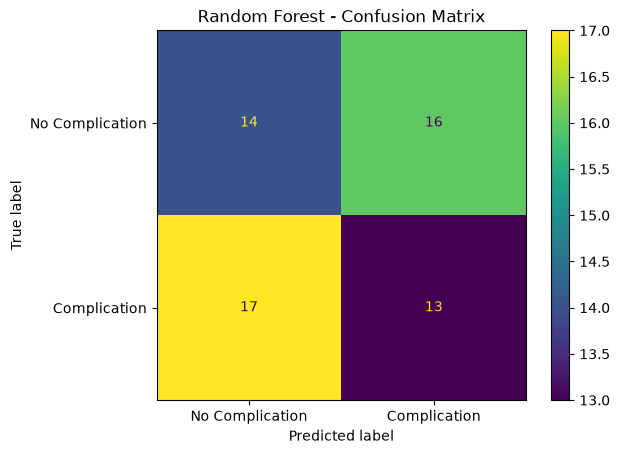

In [57]:
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["No Complication", "Complication"])

disp.plot()
plt.title("Random Forest - Confusion Matrix")
plt.show()

## ROC Curve

The ROC curve evaluates discrimination across classification thresholds.

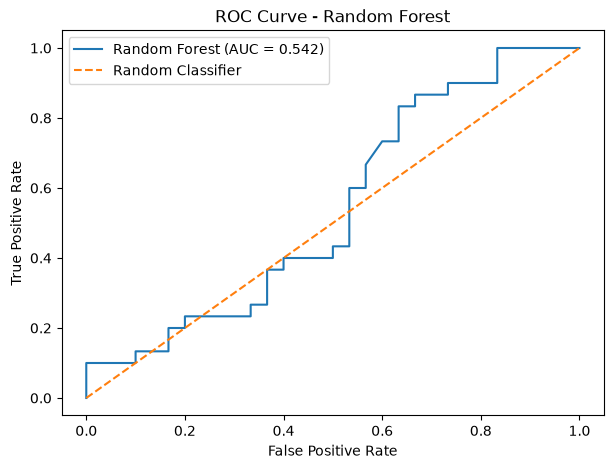

In [58]:
fpr, tpr, thresholds = roc_curve(y_test, y_prob_rf)
auc = roc_auc_score(y_test, y_prob_rf)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, label=f"Random Forest (AUC = {auc:.3f})")

plt.plot([0, 1], [0, 1], linestyle="--", label="Random Classifier")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Random Forest")
plt.legend()
plt.show()

The model has limited discriminatory ability and performs only slightly above chance level.

The tuned Random Forest achieved a test ROC-AUC of 0.542. The ROC curve remained close to the random-classifier baseline, indicating limited ability to discriminate between patients with and without complications.

Given the small sample size and limited feature set, this performance should not be interpreted as evidence of clinically useful predictive capability.

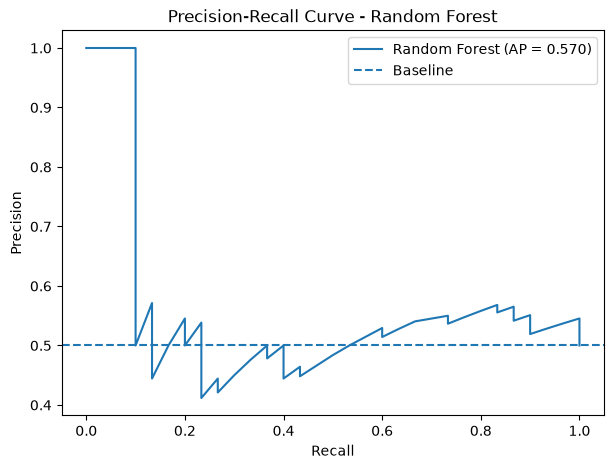

In [59]:
precision, recall, thresholds = precision_recall_curve(y_test, y_prob_rf)
average_precision = average_precision_score(y_test, y_prob_rf)

plt.figure(figsize=(7, 5))
plt.plot(recall, precision, label=f"Random Forest (AP = {average_precision:.3f})")
plt.axhline(y=y_test.mean(), linestyle="--", label="Baseline")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve - Random Forest")
plt.legend()
plt.show()

In [60]:
final_preprocessor = best_rf_model.named_steps["preprocessor"]
final_classifier = best_rf_model.named_steps["classifier"]

feature_names = final_preprocessor.get_feature_names_out()
importances = final_classifier.feature_importances_

feature_importance = (
    pd.DataFrame({"Feature": feature_names, "Importance": importances})
    .sort_values("Importance", ascending=False)
    .reset_index(drop=True)
)

display(feature_importance)


,Feature,Importance
0,num__SurgeryDuration_min,0.335461
1,num__BMI,0.164925
2,num__Age,0.160472
3,num__Has_Comorbidities,0.068511
4,cat__SurgeryType_Cosmetic,0.038263
5,cat__SurgeryType_Orthopedic,0.035204
6,cat__Gender_F,0.034479
7,cat__AnesthesiaType_General,0.034000
8,cat__Gender_M,0.033767
9,cat__SurgeryType_Neurological,0.033066


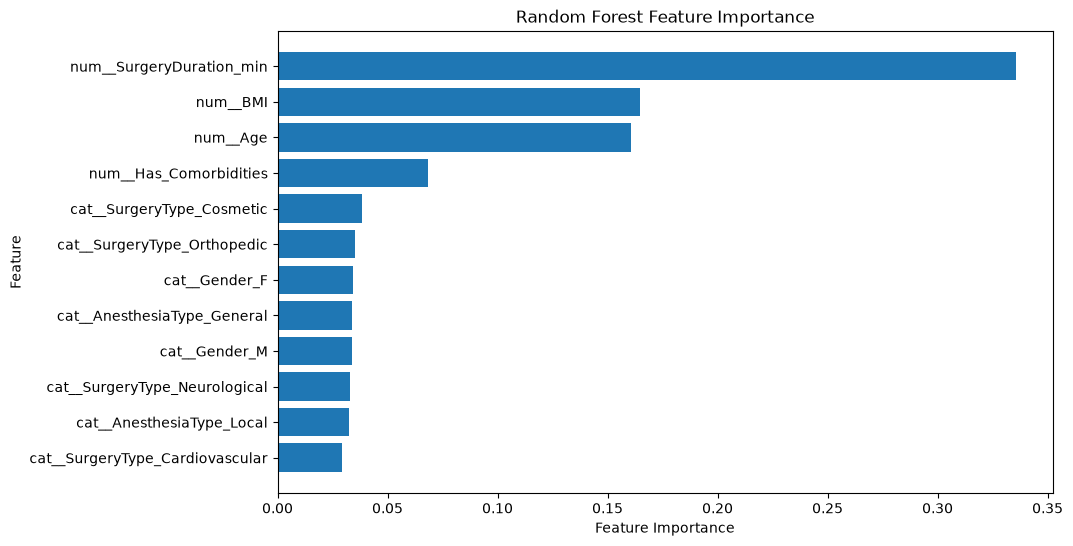

In [61]:
plt.figure(figsize=(10, 6))
plt.barh(feature_importance["Feature"], feature_importance["Importance"])
plt.gca().invert_yaxis()

plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title("Random Forest Feature Importance")

plt.show()

## Shap

SHAP provides model-specific explanations of feature contributions.

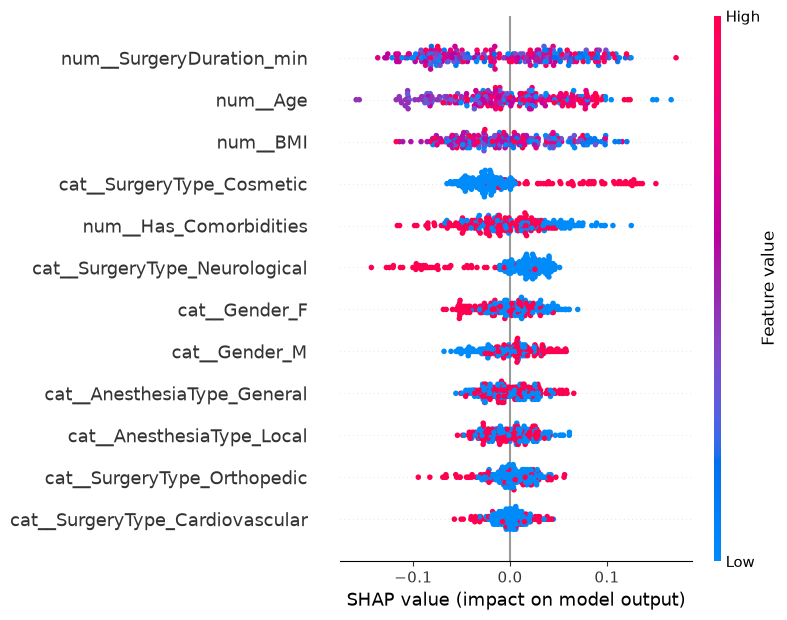

In [62]:
final_preprocessor = best_rf_model.named_steps["preprocessor"]
rf_classifier = best_rf_model.named_steps["classifier"]

X_train_processed = final_preprocessor.transform(X_train)
feature_names = final_preprocessor.get_feature_names_out()

explainer = shap.TreeExplainer(rf_classifier)
shap_result = explainer(X_train_processed)

# SHAP versions differ in how binary-class outputs are represented.
if getattr(shap_result.values, "ndim", None) == 3:
    shap_values_positive = shap_result.values[:, :, 1]
else:
    shap_values_positive = shap_result.values

shap.summary_plot(
    shap_values_positive,
    X_train_processed,
    feature_names=feature_names,
)


## Creating final model

The complete fitted preprocessing-and-model pipeline is serialized for the Streamlit application.

In [63]:
MODEL_DIR.mkdir(parents=True, exist_ok=True)

joblib.dump(best_rf_model, MODEL_PATH)

print("Model saved successfully.")
print("Model path:", MODEL_PATH)
print("Exists:", MODEL_PATH.exists())


Model saved successfully.
Model path: D:\Project\anesthesia-ml-project\models\anesthesia_rf_model.pkl
Exists: True


In [64]:
MODEL_DIR.mkdir(parents=True, exist_ok=True)

joblib.dump(best_rf_model, MODEL_PATH)

print("Model saved successfully.")
print("Model path:", MODEL_PATH)
print("Exists:", MODEL_PATH.exists())


Model saved successfully.
Model path: D:\Project\anesthesia-ml-project\models\anesthesia_rf_model.pkl
Exists: True
